# Classification Test

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from mlp import Layer, MLP
from losses import CrossEntropyLoss

from activations import LeakyRelu, SoftMax
from utils import OneHotEncoder
from sklearn.datasets import make_classification

In [2]:
X, y = make_classification(
    n_samples=500, 
    n_features=2, 
    n_informative=2, 
    n_redundant=0, 
    n_classes=2,
    class_sep=2,
    random_state=1123344,
)
encoder = OneHotEncoder()
y_onehot = encoder.encode(y)
y_int = y                 


X_train, X_test = X[:400], X[400:]
y_train, y_test = y_onehot[:400], y_onehot[400:]

In [3]:
mlp = MLP()
mlp.add_layer(Layer(2, 16, LeakyRelu()))
mlp.add_layer(Layer(16, 8, LeakyRelu()))
mlp.add_layer(Layer(8, 2, SoftMax()))

In [4]:
loss_fn = CrossEntropyLoss()
l_rate = 0.1
epochs = 20

losses = []
for epoch in range(epochs):
    epoch_loss = 0
    for x, y in zip(X_train, y_train):
        y_hat = mlp.forward(x)
        epoch_loss += loss_fn.forward(y_hat, y)
        delta = loss_fn.backward(y_hat, y)
        mlp.backward(delta)
        mlp.update(l_rate)
    losses.append(epoch_loss / len(X_train))
    print(f"Epoch {epoch+1}/{epochs} - Loss: {losses[-1]}")


Epoch 1/20 - Loss: 0.16795244742673635
Epoch 2/20 - Loss: 0.1251527619563791
Epoch 3/20 - Loss: 0.09590231160033684
Epoch 4/20 - Loss: 0.10783560243615248
Epoch 5/20 - Loss: 0.0989687471555668
Epoch 6/20 - Loss: 0.10083637157197979
Epoch 7/20 - Loss: 0.09529349136062269
Epoch 8/20 - Loss: 0.08849448256185628
Epoch 9/20 - Loss: 0.09270654572020325
Epoch 10/20 - Loss: 0.08613512623893749
Epoch 11/20 - Loss: 0.0844188714617415
Epoch 12/20 - Loss: 0.08429034475596643
Epoch 13/20 - Loss: 0.09220474333866525
Epoch 14/20 - Loss: 0.08536952361308259
Epoch 15/20 - Loss: 0.08827194529839698
Epoch 16/20 - Loss: 0.08550903268572745
Epoch 17/20 - Loss: 0.079680996535089
Epoch 18/20 - Loss: 0.08450978243183077
Epoch 19/20 - Loss: 0.08593331251064468
Epoch 20/20 - Loss: 0.08512830032831069


In [ ]:
x = X_train[0]
y_true = y_train[0]
y_pred = mlp.forward(x)
delta = loss_fn.backward(y_pred, y_true)
mlp.backward(delta)

print("delta from loss:", delta)
print("layer3 grad_weights mean:", mlp.layers[2].grad_weights.mean())
print("layer2 grad_weights mean:", mlp.layers[1].grad_weights.mean())
print("layer1 grad_weights mean:", mlp.layers[0].grad_weights.mean())

delta from loss: [ 0.00071649 -0.00071649]
layer3 grad_weights mean: 3.742485375523078e-17
layer2 grad_weights mean: -7.209058065172222e-05
layer1 grad_weights mean: -0.0003958998302470659


In [6]:
correct = 0
for x, y in zip(X_test, y_test):
    y_pred = mlp.forward(x)
    if np.argmax(y_pred) == np.argmax(y):
        correct += 1

accuracy = correct / len(X_test)
print(f"Test accuracy: {accuracy * 100}%")

Test accuracy: 99.0%


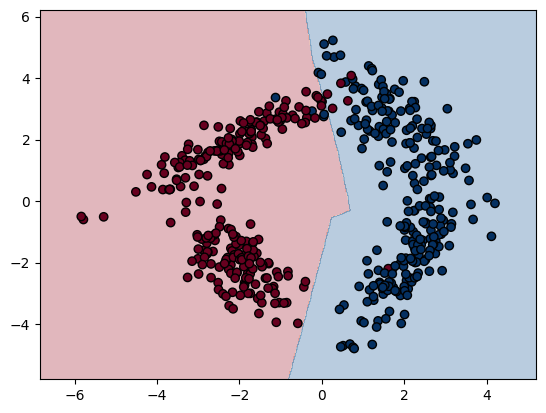

In [7]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

grid = np.c_[xx.ravel(), yy.ravel()]
Z = np.array([np.argmax(mlp.forward(point)) for point in grid])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(X[:, 0], X[:, 1], c=np.argmax(y_onehot, axis=1), edgecolors='k', cmap='RdBu')
plt.show()